Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cosine Similarity Matrix:

[[ 1.0000004   0.57068485  0.3420955   0.14753105  0.07659664  0.1340586
   0.02962481  0.11631595  0.03260526 -0.10783168]
 [ 0.57068485  1.0000004   0.45253313  0.03983232  0.04535843  0.0593524
  -0.04463285  0.08975866  0.04642308 -0.04762397]
 [ 0.3420955   0.45253313  1.0000001   0.170015   -0.01530901  0.06682447
  -0.05074985 -0.04601192  0.09855513 -0.00140811]
 [ 0.14753105  0.03983232  0.170015    1.0000002   0.30702835  0.36070037
  -0.05010106  0.00841054  0.00650369  0.02881224]
 [ 0.07659664  0.04535843 -0.01530901  0.30702835  1.          0.13885753
  -0.00365631  0.03306204  0.01670963 -0.0024977 ]
 [ 0.1340586   0.0593524   0.06682447  0.36070037  0.13885753  1.
  -0.08831599  0.05073386  0.12717444  0.00492465]
 [ 0.02962481 -0.04463285 -0.05074985 -0.05010106 -0.00365631 -0.08831599
   0.9999998   0.3149947   0.35883513  0.35538137]
 [ 0.11631595  0.08975866 -0.04601192  0.00841054  0.03306204  0.05073386
   0.3149947   0.99999994  0.46694

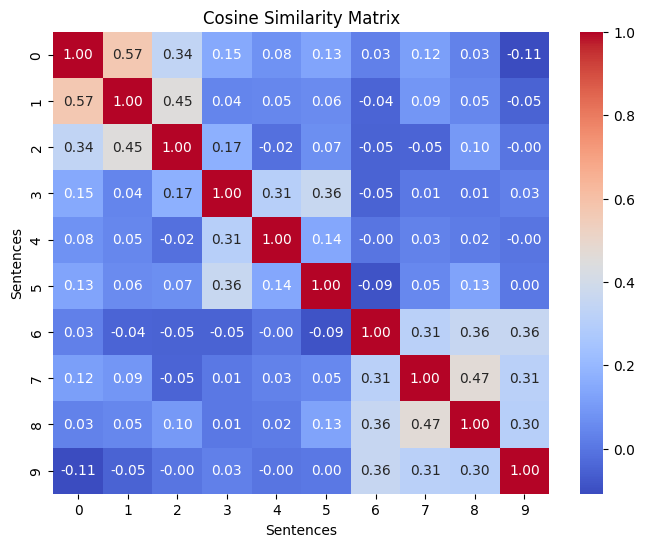


Query: The bowler took three wickets in one over

Top 2 most similar sentences:

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5707

Sentence: The team celebrated their victory after the match
Similarity Score: 0.3421


In [2]:
# Step 1: Install required library
!pip install sentence-transformers

# Step 2: Import libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Step 3: Create 10 sentences (3 topics: Cricket, Cooking, Cybersecurity)
sentences = [
    # Cricket
    "The bowler took three wickets in one over",
    "The batsman scored a century in the final match",
    "The team celebrated their victory after the match",

    # Cooking
    "I cooked a delicious biryani for dinner",
    "The recipe requires fresh vegetables and spices",
    "She baked a chocolate cake in the oven",

    # Cybersecurity
    "Strong passwords help protect your online accounts",
    "Cyber attacks can compromise sensitive data",
    "Encryption ensures secure communication over the internet",

    # Extra (to make 10)
    "Firewalls help in preventing unauthorized access"
]

# Step 4: Load embedding model (IMPORTANT)
model = SentenceTransformer('all-MiniLM-L6-v2')

# Step 5: Generate embeddings
embeddings = model.encode(sentences)

# Step 6: Compute cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Step 7: Print matrix
print("Cosine Similarity Matrix:\n")
print(similarity_matrix)

# Step 8: Plot heatmap WITH numbers
plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Cosine Similarity Matrix")
plt.xlabel("Sentences")
plt.ylabel("Sentences")

plt.show()

# Step 9: Query sentence
query = "The bowler took three wickets in one over"

# Encode query
query_embedding = model.encode([query])

# Compute similarity with all sentences
scores = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 similar sentences (excluding itself)
similar_indices = scores.argsort()[-3:-1][::-1]

print("\nQuery:", query)
print("\nTop 2 most similar sentences:")

for idx in similar_indices:
    print(f"\nSentence: {sentences[idx]}")
    print(f"Similarity Score: {scores[idx]:.4f}")